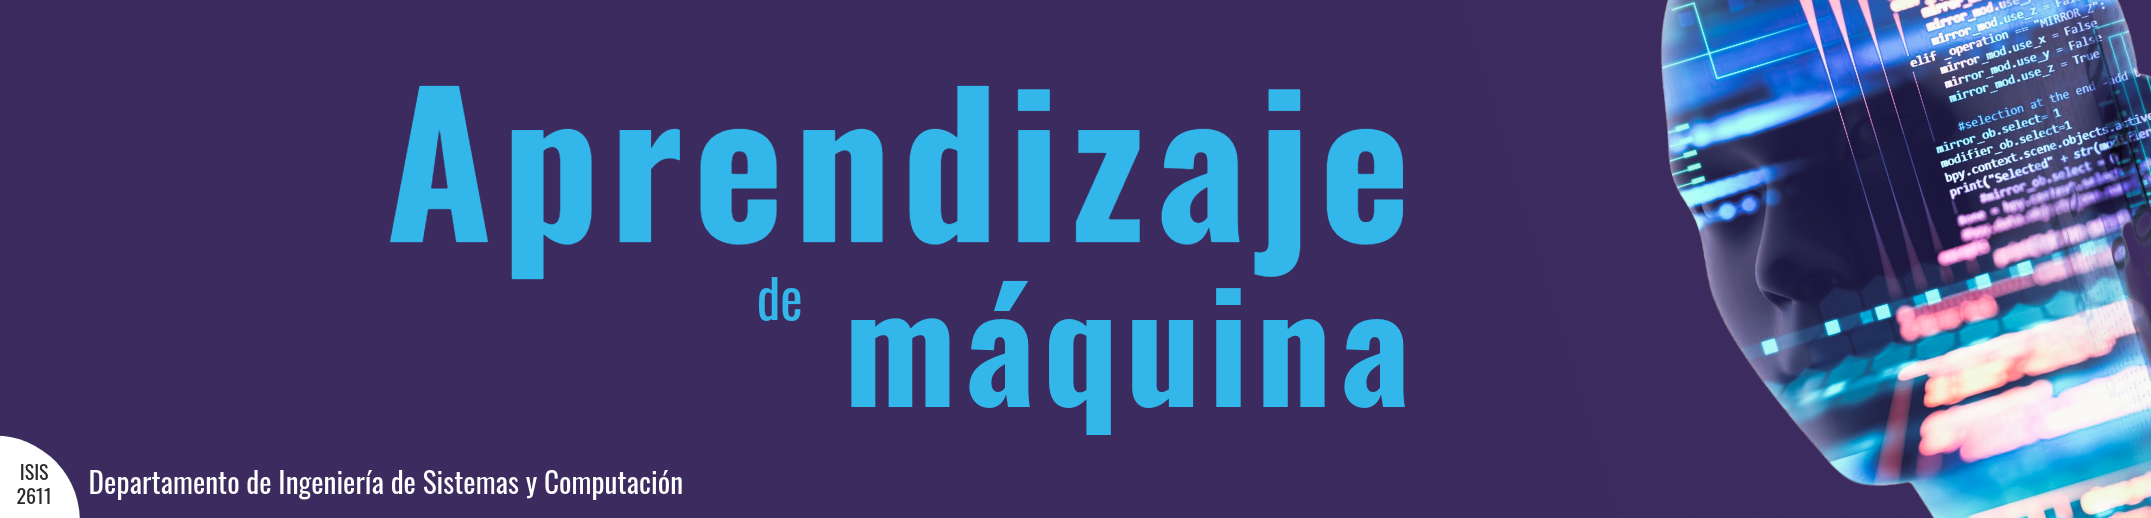

# Practica 14: Redes Convolucionales y Control de Complejidad

# Introducción

En esta práctica exploramos el diseño y entrenamiento de **Redes Neuronales Convolucionales (CNN)** para clasificación de imágenes usando CIFAR-10. Partimos de un modelo base desde cero y luego incorporamos **transfer learning** y **fine-tuning** con modelos preentrenados para mejorar el rendimiento y la eficiencia.

---
## Guía de Configuración: Aceleración por Hardware

Para entrenar modelos de Deep Learning de manera eficiente, es fundamental aprovechar la aceleración por hardware (**GPU** o **TPU**). En Google Colab, puedes activar esto de la siguiente manera:

1. Dirígete al menú superior y selecciona **Entorno de ejecución** (Runtime).
2. Haz clic en **Cambiar tipo de entorno de ejecución** (Change runtime type).
3. En el desplegable de **Acelerador de hardware**, selecciona **T4 GPU** (recomendado para MLPs y CNNs estándar).
4. Haz clic en **Guardar**.

> **Nota:** La GPU (Graphics Processing Unit) está diseñada para el procesamiento en paralelo masivo, lo cual acelera drásticamente las multiplicaciones de matrices y el cálculo de gradientes en TensorFlow.

### Verificación del Entorno
Ejecuta la siguiente celda para confirmar que TensorFlow tiene acceso a la GPU:

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers, models

# Validar conexion con GPU
device_name = tf.test.gpu_device_name()
if not device_name:
    print('GPU no encontrada.')
else:
    print(f'Instancia de GPU detectada: {device_name}')

# Limitar la verbosidad de logs de TF
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

Instancia de GPU detectada: /device:GPU:0


Ahora empecemos con la carga de datos y una exploracion al dataset

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 216s 1us/step
Forma de los datos de entrenamiento: (50000, 32, 32, 3)
Forma de los datos de prueba: (10000, 32, 32, 3)
Cada imagen tiene 3072 valores de entrada.
Distribucion: 50000 imagenes de entrenamiento, 10000 de prueba.


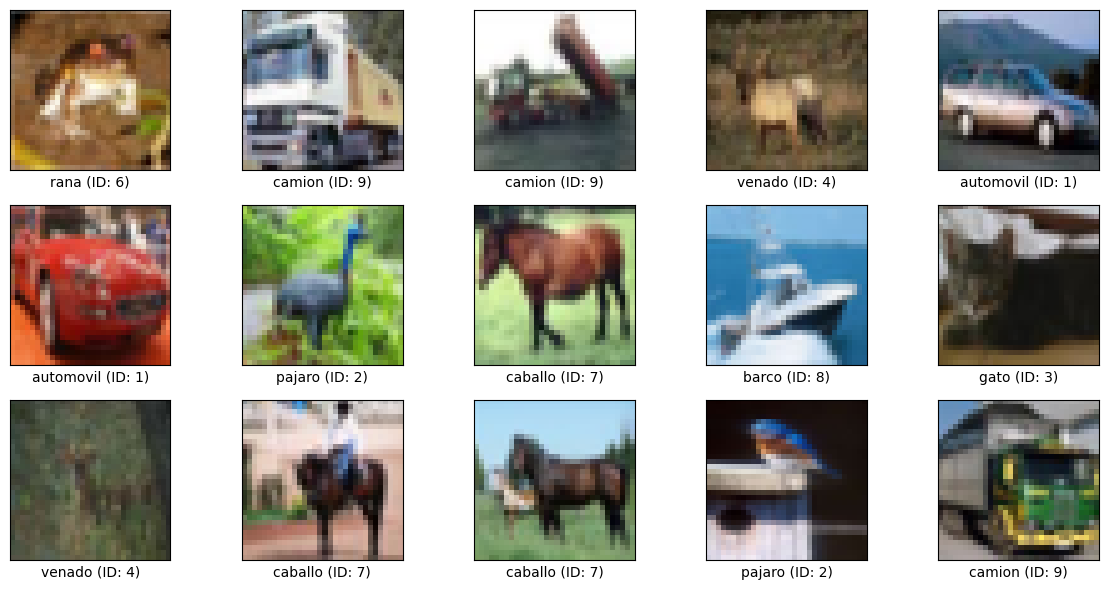

In [2]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

# 1. Carga de datos
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# 2. Analisis de forma
# Es vital entender que la forma es (Batch, Height, Width, Channels)
print(f"Forma de los datos de entrenamiento: {train_images.shape}")
print(f"Forma de los datos de prueba: {test_images.shape}")
print(f"Cada imagen tiene {train_images.shape[1] * train_images.shape[2] * train_images.shape[3]} valores de entrada.")
print(f"Distribucion: {train_images.shape[0]} imagenes de entrenamiento, {test_images.shape[0]} de prueba.")

# 3. Normalizacion
# Los pixeles vienen en rango [0, 255]. Dividimos por 255 para escalar a [0, 1].
# Esto ayuda a que el gradiente no explote durante el entrenamiento.
train_images, test_images = train_images / 255.0, test_images / 255.0

# 4. Visualizacion detallada
class_names = ['avion', 'automovil', 'pajaro', 'gato', 'venado',
               'perro', 'rana', 'caballo', 'barco', 'camion']

plt.figure(figsize=(12, 6))
for i in range(15):
    plt.subplot(3, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    plt.xlabel(f"{class_names[train_labels[i][0]]} (ID: {train_labels[i][0]})")
plt.tight_layout()
plt.show()

### Visualización de una imagen por cada clase
A continuación mostramos un ejemplo representativo de cada una de las 10 clases del dataset CIFAR-10.


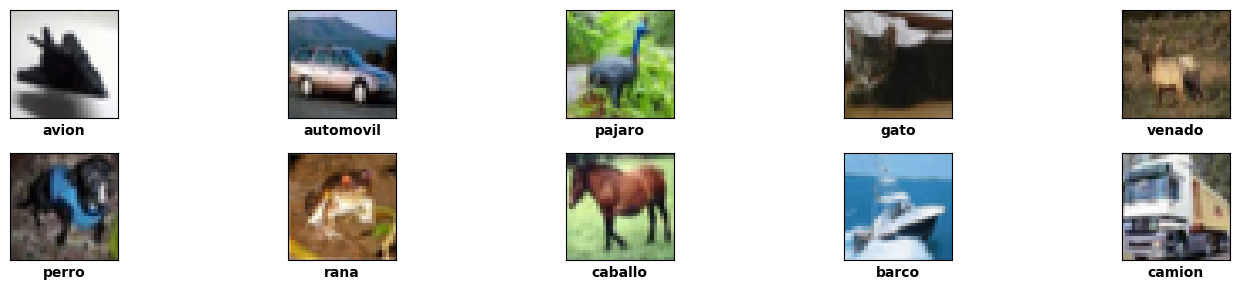

In [3]:
plt.figure(figsize=(15, 3))
for i in range(10):
    # Buscar la primera imagen de cada clase
    idx = np.where(train_labels == i)[0][0]
    plt.subplot(2, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[idx])
    plt.xlabel(f"{class_names[i]}", fontweight='bold')
plt.tight_layout()
plt.show()

---
## 2. Fundamentos de las Redes Neuronales Convolucionales (CNN)

A diferencia de los modelos densos (MLP), que procesan la información de manera global y pierden la relación espacial de los datos, las CNN se basan en el principio de **localidad biológica**. Estas redes extraen características jerárquicas mediante operaciones matemáticas específicas que preservan la topología de la imagen.

Por ejemplo, en un MLP, si se hace un desplazamiento de píxeles, el vector que entiende el modelo es totalmente diferente. Una CNN resuelve esto al aplicar un análisis teniendo en cuenta la topografía (los píxeles vecinos).

A continuación, explicaremos cada capa que compone una arquitectura CNN de forma individual.

### 2.1 Capa Convolucional (Conv2D)

La operación fundamental de una CNN es la **convolución**. El núcleo de esta arquitectura es el **kernel** o filtro: una matriz de pesos de dimensiones reducidas (comúnmente 3x3 o 5x5) que se desplaza a lo largo de los ejes de la imagen de entrada.

**Cómo funciona:**
- El filtro recorre la imagen realizando multiplicaciones elemento a elemento y sumando los resultados.
- Cada filtro detecta un patrón específico: bordes verticales, horizontales, texturas, etc.
- Los filtros iniciales detectan características simples (líneas, bordes), mientras que los filtros profundos detectan formas complejas (ojos, ruedas, alas).

**Parámetros clave:**
- `filters`: número de filtros (cada uno genera un mapa de características).
- `kernel_size`: tamaño del filtro (3x3, 5x5).
- `padding`: `'same'` mantiene el tamaño de salida; `'valid'` lo reduce.
- `activation`: generalmente `'relu'` para introducir no linealidad.

![Diagrama de Convolución 2D](images\conv2d.png)

*Figura: un filtro 3x3 se desliza sobre la imagen de entrada, produciendo un mapa de características.*

**Ejemplo en Keras:**
```python
layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3))
```

Matemáticamente, para una imagen `I` y un kernel `K`, la operación de convolución en la posición `(i, j)` se define como:

$$(I * K)(i, j) = \sum_{m} \sum_{n} I(i+m, j+n) \cdot K(m, n)$$

**Weight sharing (reutilización de pesos):** un mismo kernel se aplica a toda la imagen. Esto reduce drásticamente el número de parámetros en comparación con una capa densa y permite detectar patrones independientemente de su ubicación.

### 2.2 Capa de Normalización por Lote (BatchNormalization)

Durante el entrenamiento, la distribución de las entradas de cada capa cambia constantemente debido a la actualización de los pesos de las capas anteriores. Este fenómeno se conoce como **covariate shift interno** y puede desestabilizar el aprendizaje.

**Cómo funciona:**
1. Calcula la media y la varianza de las activaciones del lote actual.
2. Normaliza las activaciones: `x_hat = (x - mu) / sqrt(sigma^2 + epsilon)`
3. Reescala y desplaza con parámetros aprendibles (`gamma`, `beta`).

**Beneficios:**
- Permite usar **learning rates más altos** sin que el entrenamiento diverja.
- Acelera la **convergencia** significativamente.
- Actúa como un **regularizador leve**, reduciendo la necesidad de Dropout en algunos casos.
- Mitiga problemas de **desvanecimiento del gradiente**.


**Ejemplo en Keras:**
```python
layers.BatchNormalization()
```

### 2.3 Capa de Max Pooling (MaxPooling2D)

Tras la detección de características mediante la convolución, es importante reducir la sensibilidad del modelo a variaciones posicionales. La operación de **Max Pooling** realiza un submuestreo no lineal al seleccionar el valor máximo dentro de una ventana local (comúnmente de 2x2 píxeles).

**Cómo funciona:**
- Toma una ventana de 2x2 sobre el mapa de características.
- Selecciona el valor máximo de esa ventana.
- La ventana se desplaza (generalmente con `stride=2`), reduciendo la dimensión espacial a la mitad.

**Beneficios:**
- **Invarianza a la traslación local:** si una característica se desplaza levemente, el pooling sigue reportando su presencia.
- **Reducción de dimensionalidad:** una ventana de 2x2 reduce los datos en un 75%, disminuyendo la carga computacional.
- **Campo receptivo ampliado:** las capas profundas pueden procesar áreas más extensas de la imagen original.

![Diagrama de Max Pooling](images\maxpool2d.png)

*Figura: Max Pooling 2x2 selecciona el valor máximo de cada ventana, reduciendo la resolución espacial.*

**Ejemplo en Keras:**
```python
layers.MaxPooling2D((2, 2))  # Reduce 32x32 a 16x16
```

### 2.4 Capa de Dropout

El dropout es una técnica de regularización que previene el sobreajuste. Durante el entrenamiento, **desactiva aleatoriamente** una proporción de neuronas en cada paso de *forward propagation*.

**Cómo funciona:**
- En cada iteración, una fracción de neuronas se "apaga" (su salida se multiplica por 0).
- Las neuronas activas se reescalan para compensar las desactivadas.
- Durante la inferencia (predicción), **todas las neuronas están activas**.

**Beneficios:**
- Previene la **coadaptación** de neuronas (que dependan unas de otras).
- Obliga a la red a aprender representaciones **redundantes y robustas**.
- Mejora significativamente la **generalización** ante datos no observados.

![Diagrama de Dropout](images\dropout.png)

*Figura: izquierda: red completa. Derecha: red con dropout aplicado (neuronas grises desactivadas).*

**Ejemplo en Keras:**
```python
layers.Dropout(0.3)  # Apaga el 30% de las neuronas aleatoriamente
```

### 2.5 Capa de Aplanado (Flatten)

La capa `Flatten` convierte la salida multidimensional de las capas convolucionales en un **vector unidimensional**. Este vector servirá como entrada para las capas densas de clasificación.

**Cómo funciona:**
- Toma un tensor de forma `(batch, altura, anchura, canales)`.
- Lo aplana en un vector de forma `(batch, altura * anchura * canales)`.

**Ejemplo:**
Si la salida anterior es `(None, 8, 8, 64)`, `Flatten` produce `(None, 4096)`.

**Ejemplo en Keras:**
```python
layers.Flatten()
```

### 2.6 Capa Densa (Dense)

Las capas densas (*fully connected*) son las encargadas de la **clasificación final**. Cada neurona está conectada a todas las neuronas de la capa anterior, lo que permite combinar las características extraídas por las capas convolucionales para tomar una decisión.

**Cómo funciona:**
- Cada neurona calcula: `y = activation(W * x + b)`
- La última capa densa tiene tantas neuronas como clases del problema (10 para CIFAR-10).
- La función de activación de la última capa es generalmente `softmax` para clasificación multiclase.

**Ejemplo en Keras:**
```python
layers.Dense(128, activation='relu')
layers.Dense(10, activation='softmax')
```

### 2.7 Arquitectura CNN Completa

Una arquitectura CNN típica organiza estas capas en **bloques**:

![Arquitectura CNN Completa](images\cnn.png)

*Figura: flujo típico de una CNN: entrada > bloques convolucionales > Flatten > capas densas > salida.*

| Bloque                     | Función                         | Capas típicas                                      |
|--------------------------|----------------------------------|---------------------------------------------------|
| Bloque 1 (bajo nivel)    | Detecta bordes, texturas         | Conv2D + BN + Conv2D + MaxPool + Dropout          |
| Bloque 2 (medio nivel)   | Detecta formas complejas         | Conv2D + BN + Conv2D + MaxPool + Dropout          |
| Clasificador             | Combina y clasifica              | Flatten + Dense + BN + Dropout + Dense            |

A continuación, construimos nuestro modelo *baseline* siguiendo esta estructura.

In [4]:
def construir_modelo_cnn():
    model = models.Sequential()

    # BLOQUE 1: Extraccion de bajo nivel (Bordes y Texturas)
    # Usamos 32 filtros de 3x3. El parametro 'same' padding mantiene el tamano de la imagen.
    model.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)))
    model.add(layers.BatchNormalization()) # Estabiliza el aprendizaje
    model.add(layers.Conv2D(32, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2))) # Reduce 32x32 a 16x16
    model.add(layers.Dropout(0.2)) # Apaga el 20% de neuronas

    # BLOQUE 2: Extraccion de medio nivel (Formas complejas)
    model.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2))) # Reduce 16x16 a 8x8
    model.add(layers.Dropout(0.3))

    # BLOQUE 3: Clasificador Final
    model.add(layers.Flatten()) # Convertir matriz a vector plano
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(10, activation='softmax')) # 10 neuronas para las 10 clases

    return model


# Compilar y revisar la arquitectura
cnn_baseline = construir_modelo_cnn()
cnn_baseline.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
cnn_baseline.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 15, 15, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 362,794 (1.38 MB)

 Trainable params: 362,346 (1.38 MB)

 Non-trainable params: 448 (1.75 KB)

### Entrenamiento del Modelo Baseline (Referencia)

Para evaluar el desempeño de nuestra arquitectura propia, iniciaremos el proceso de entrenamiento. Es fundamental implementar mecanismos de control para evitar el uso innecesario de recursos y asegurar la captura de los mejores pesos.

#### Definición de callbacks

Utilizaremos dos controladores dinámicos:
1. **EarlyStopping:** detendrá el entrenamiento si la pérdida de validación (`val_loss`) deja de disminuir durante 5 épocas consecutivas. Esto previene el sobreajuste.
2. **ReduceLROnPlateau:** si el modelo se estanca en una meseta de pérdida, reducirá la tasa de aprendizaje a la mitad. Esto permite ajustes más finos del optimizador.

In [5]:
# Configuracion de los callbacks de control
callbacks_baseline = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

# Entrenamiento
history_baseline = cnn_baseline.fit(
    train_images, train_labels,
    epochs=30,
    batch_size=64,
    validation_data=(test_images, test_labels),
    callbacks=callbacks_baseline
)

Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 20ms/step - accuracy: 0.4569 - loss: 1.5521 - val_accuracy: 0.3860 - val_loss: 1.8713 - learning_rate: 0.0010
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - accuracy: 0.6159 - loss: 1.0885 - val_accuracy: 0.6687 - val_loss: 0.9286 - learning_rate: 0.0010
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.6731 - loss: 0.9361 - val_accuracy: 0.6897 - val_loss: 0.8809 - learning_rate: 0.0010
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7038 - loss: 0.8547 - val_accuracy: 0.7073 - val_loss: 0.8237 - learning_rate: 0.0010
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7286 - loss: 0.7850 - val_accuracy: 0.7449 - val_loss: 0.7368 - learning_rate: 0.0010
Epoch 6/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7467 - loss: 0.7388 - val_accuracy: 0.7306 - val_loss: 0.7958 - learning_rate: 0.0010
Epoch 7/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7547 - loss: 0.706

### Análisis de Resultados: Modelo CNN Baseline

Al comparar el desempeño entre los conjuntos:
- **Entrenamiento:** accuracy final de **~87.4%**.
- **Validación:** accuracy final de **~83.1%**.

La brecha (*gap*) de aproximadamente 4% entre ambas métricas sugiere que los mecanismos de regularización implementados (**Dropout** y **BatchNormalization**) han cumplido su función de mitigar el sobreajuste. Sin embargo, la oscilación de `val_loss` cerca de **0.50** indica que el modelo está llegando al límite de su capacidad representacional.

#### Limitaciones del modelo propio

A partir de la época 24, las mejoras en la pérdida de validación son marginales. Esto sugiere que, para superar el umbral del 85–90% de precisión, conviene explorar técnicas más avanzadas como los **modelos preentrenados** y el **aprendizaje por transferencia**.

---

## 3. Modelos Preentrenados

Hasta ahora, hemos construido y entrenado un modelo desde cero. Sin embargo, en la práctica profesional es común aprovechar modelos ya entrenados con *datasets* masivos.

### 3.1 ¿Qué son los modelos preentrenados?

Un modelo preentrenado es una red neuronal que ya fue entrenada con un *dataset* grande (generalmente **ImageNet**, con 1.2 millones de imágenes y 1000 categorías). Estos modelos aprenden a detectar características visuales universales como bordes, texturas, formas y objetos complejos.

**¿Por qué usarlos?**
- **Ahorro de tiempo:** no necesitas entrenar desde cero.
- **Menos datos necesarios:** el modelo ya conoce patrones generales.
- **Mejor rendimiento:** los modelos preentrenados en ImageNet están altamente optimizados.

**¿Dónde encontrarlos?**
- [Keras Applications](https://keras.io/api/applications/): VGG16, VGG19, ResNet, MobileNet, EfficientNet, etc.
- [TensorFlow Hub](https://tfhub.dev/)
- [Hugging Face](https://huggingface.co/models)

### 3.2 Explorando VGG16 como ejemplo

VGG16 es una arquitectura clásica desarrollada por el *Visual Geometry Group* de Oxford. Fue uno de los modelos más exitosos en ImageNet 2014.

Vamos a cargar VGG16 preentrenado y explorar su estructura.

In [6]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input, decode_predictions

# Cargar VGG16 pre-entrenado con pesos de ImageNet
vgg16 = VGG16(weights='imagenet')

print("=== Arquitectura VGG16 Pre-entrenada ===")
vgg16.summary()

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
=== Arquitectura VGG16 Pre-entrenada ===


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

### Análisis de VGG16

Observemos aspectos clave del resumen del modelo:

| Aspecto                 | Valor           | Significado                                      |
|------------------------|-----------------|--------------------------------------------------|
| Dimensión de entrada   | (224, 224, 3)   | Espera imágenes RGB de 224x224 píxeles           |
| Dimensión de salida    | (1000,)         | 1000 neuronas = 1000 categorías de ImageNet      |
| Parámetros totales     | ~138 millones   | Modelo muy grande y potente                      |

Nótese que VGG16 tiene **138 millones de parámetros**, comparado con ~362,000 de nuestro modelo *baseline*. Esta diferencia explica por qué los modelos preentrenados pueden lograr mejor rendimiento.

### 3.3 Haciendo una predicción con VGG16

Para usar un modelo preentrenado, debemos **preprocesar** las imágenes de la misma manera que durante el entrenamiento original. Keras proporciona la función `preprocess_input` para esto.

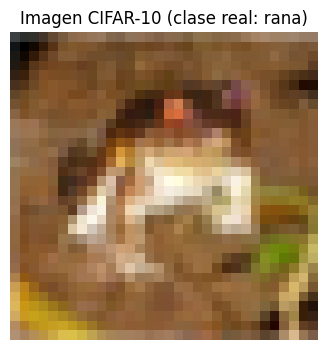

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Top-3 predicciones de VGG16 (ImageNet):
1. rock_python: 0.0568
2. consomme: 0.0527
3. Brabancon_griffon: 0.0362


In [7]:
# Usamos una imagen del propio dataset CIFAR-10
sample_idx = 0
sample_img = train_images[sample_idx]  # Ya esta normalizada en [0, 1]
sample_label = class_names[int(train_labels[sample_idx][0])]

plt.figure(figsize=(4, 4))
plt.imshow(sample_img)
plt.axis('off')
plt.title(f'Imagen CIFAR-10 (clase real: {sample_label})')
plt.show()

# VGG16 requiere entrada 224x224 y preprocesamiento tipo ImageNet
sample_img_255 = (sample_img * 255.0).astype(np.float32)
resized = tf.image.resize(sample_img_255, (224, 224)).numpy()
input_batch = np.expand_dims(resized, axis=0)
input_batch = preprocess_input(input_batch)

preds = vgg16.predict(input_batch, verbose=0)
top3 = decode_predictions(preds, top=3)[0]

print('Top-3 predicciones de VGG16 (ImageNet):')
for i, (_, label, score) in enumerate(top3, start=1):
    print(f'{i}. {label}: {score:.4f}')


### 3.4 Limitaciones de usar modelos preentrenados directamente

VGG16 predice categorías de ImageNet. Si intentáramos usarlo directamente para CIFAR-10:
1. **Las categorías no coinciden:** las 1000 clases de ImageNet no son las 10 de CIFAR-10.
2. **Las dimensiones de entrada son diferentes:** VGG16 espera 224x224, CIFAR-10 usa 32x32.
3. **No es óptimo para nuestro problema específico.**

Aquí entra el **transfer learning**: tomamos el conocimiento visual general del modelo preentrenado y lo adaptamos a nuestra tarea específica.

---

## 4. Aprendizaje por Transferencia (Transfer Learning)

### 4.1 ¿Qué es Transfer Learning?

El *transfer learning* es la técnica de tomar un modelo preentrenado y **reutilizarlo** como punto de partida para una tarea diferente pero relacionada.

**Analogía:** piensa en un músico clásico que quiere aprender jazz. Ya conoce teoría y técnica; no empieza desde cero, solo adapta sus habilidades.

**¿Cuándo usar Transfer Learning?**
- Tienes un **dataset pequeño** (como CIFAR-10 con 50k imágenes vs. ImageNet con 1.2M).
- Quieres **ahorrar tiempo** de entrenamiento.
- Necesitas **mejor rendimiento** que el de un modelo entrenado desde cero.

### 4.2 Dos enfoques de Transfer Learning

Existen dos estrategias principales:

| Estrategia              | Descripción                                                                 | Cuándo usarla                                      |
|------------------------|-----------------------------------------------------------------------------|----------------------------------------------------|
| **Feature Extraction** | Congelar el modelo base y entrenar solo la nueva capa de clasificación     | Dataset pequeño, modelo base relevante              |
| **Fine-Tuning**        | Descongelar parte o todo el modelo base y reentrenar con *learning rate* bajo | Dataset mediano, necesitas mayor adaptación         |

Utilizaremos **MobileNetV2**, una arquitectura optimizada para eficiencia computacional y preentrenada con ImageNet.

### 4.3 Preparando el modelo base: `include_top=False`

Al cargar el modelo usamos `include_top=False` para eliminar la capa de clasificación original de 1000 clases. Esto permite agregar nuestra propia salida de 10 clases (CIFAR-10).

In [8]:
# 1. Carga del modelo base pre-entrenado
# include_top=False elimina la capa final original de 1,000 clases
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(32, 32, 3),
    include_top=False,
    weights='imagenet'
)

print("=== Modelo Base MobileNetV2 (sin capa de clasificacion) ===")
base_model.summary()

/tmp/ipykernel_15969/769461315.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
=== Modelo Base MobileNetV2 (sin capa de clasificacion) ===


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 16, 16,    │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 16, 16,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 16, 16,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 16, 16,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 16, 16,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 16, 16,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 16, 16,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 16, 16,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 17, 17,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 8, 8, 96)  │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 8, 8, 96)  │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 8, 8, 96)  │          0 │ block_1_depthwis… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 8, 8, 24)  │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

### 4.4 Congelamiento de capas (Freezing)
Antes de agregar nuevas capas, debemos **congelar** el modelo base:

```python
base_model.trainable = False
```

#### ¿Qué significa congelar?

Cuando establecemos `trainable = False`:
- Los pesos de esas capas **no se actualizan** durante el entrenamiento.
- Los gradientes **no fluyen** hacia esas capas durante *backpropagation*.
- El modelo actúa como un **extractor de características fijo**.

#### ¿Por qué congelar?

1. **Preservar conocimiento preentrenado:** MobileNetV2 ya detecta bordes, texturas y formas universales.
2. **Entrenamiento más rápido:** se actualizan muchos menos parámetros.
3. **Menor riesgo de sobreajuste:** con pocos datos, entrenar millones de parámetros induce memorización.

#### Riesgo de descongelar demasiado pronto

Si descongelamos las capas base antes de que la nueva cabeza aprenda, los gradientes grandes pueden deteriorar los pesos preentrenados.

Por eso, el orden recomendado es:
1. Entrenar primero con capas congeladas.
2. Hacer *fine-tuning* después, con un *learning rate* muy bajo.


In [9]:
# 2. Congelacion del modelo base
base_model.trainable = False

print(f"Parametros entrenables del modelo base: {base_model.count_params()}")
print(f"base_model.trainable = {base_model.trainable}")

# 3. Construccion de la nueva arquitectura (Top Model)
model_transfer = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),  # Reduce cada mapa a su promedio
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')  # 10 clases de CIFAR-10
])

# 4. Compilacion
model_transfer.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

model_transfer.summary()

Parametros entrenables del modelo base: 2257984
base_model.trainable = False


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Análisis de parámetros tras el congelamiento

Observen la diferencia clave en el resumen:

| Tipo de parámetros     | Cantidad       | Qué representan             |
|-----------------------|----------------|-----------------------------|
| **Total params**      | ~2.2 millones  | Todo el modelo              |
| **Trainable params**  | ~12,810        | Solo la capa Dense final    |
| **Non-trainable params** | ~2.2 millones  | MobileNetV2 congelado       |

Solo ~0.5% de los parámetros son entrenables. Esto permite converger rápido usando características preexistentes.

### 4.5 GlobalAveragePooling2D vs Flatten

En el *baseline* usamos `Flatten`; aquí usamos `GlobalAveragePooling2D`:

| Característica            | Flatten                         | GlobalAveragePooling2D        |
|---------------------------|----------------------------------|-------------------------------|
| Parámetros resultantes    | altura * anchura * canales       | canales                       |
| Tamaño de salida          | Grande (ej. 4096)                | Pequeño (ej. 1280)            |
| Robustez a posición       | Baja                             | Alta                          |
| Riesgo de overfitting     | Mayor                            | Menor                         |

`GlobalAveragePooling2D` calcula el promedio de cada mapa de características y crea un vector compacto, menos propenso al sobreajuste.

### 4.6 Entrenamiento con capas congeladas

In [10]:
# Callbacks para transfer learning
callbacks_transfer = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

print("Iniciando entrenamiento del modelo con Transfer Learning (capas congeladas)...")

# Entrenamiento
history_transfer = model_transfer.fit(
    train_images, train_labels,
    epochs=25,
    batch_size=64,
    validation_data=(test_images, test_labels),
    callbacks=callbacks_transfer
)

Iniciando entrenamiento del modelo con Transfer Learning (capas congeladas)...
Epoch 1/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 39s 30ms/step - accuracy: 0.2406 - loss: 2.1239 - val_accuracy: 0.3004 - val_loss: 2.0141 - learning_rate: 0.0010
Epoch 2/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.2804 - loss: 2.0098 - val_accuracy: 0.3062 - val_loss: 1.9606 - learning_rate: 0.0010
Epoch 3/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.2897 - loss: 1.9767 - val_accuracy: 0.3094 - val_loss: 1.9373 - learning_rate: 0.0010
Epoch 4/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.2903 - loss: 1.9637 - val_accuracy: 0.3132 - val_loss: 1.9251 - learning_rate: 0.0010
Epoch 5/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.2950 - loss: 1.9535 - val_accuracy: 0.3148 - val_loss: 1.9188 - learning_rate: 0.0010
Epoch 6/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.2960 - loss: 1.9493 - val_accuracy: 0.3179 - val_loss: 1.9137 - learning_rate: 0.0010
Epoch 7

### 4.7 Fine-Tuning (Entrenamiento fino)

Ahora que la capa de clasificación ya está entrenada, aplicamos **fine-tuning**: descongelar el modelo base y entrenarlo con un **learning rate muy bajo**.

#### ¿Por qué un learning rate tan bajo?

- Los pesos preentrenados ya son buenos y solo requieren pequeños ajustes.
- Un *learning rate* alto puede destruir el conocimiento adquirido en ImageNet.
- El *fine-tuning* es un ajuste fino, no un reentrenamiento total.

#### Proceso de fine-tuning

1. Descongelar el modelo base: `base_model.trainable = True`.
2. Usar un *learning rate* muy bajo (0.00001 o menor).
3. Entrenar pocas épocas adicionales.
4. Verificar si mejora la validación.

In [11]:
# Descongelar el modelo base para fine-tuning
base_model.trainable = True

# Es importante RECOMPILAR despues de cambiar trainable
model_finetune = model_transfer  # Reutilizamos el modelo

model_finetune.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.00001),  # Learning rate MUY bajo
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("=== Fine-Tuning: Modelo con todas las capas entrenables ===")
model_finetune.summary()

=== Fine-Tuning: Modelo con todas las capas entrenables ===


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 2,236,682 (8.53 MB)

 Non-trainable params: 34,112 (133.25 KB)

Noten que ahora los **Trainable params** son ~2.2 millones (todos). Sin embargo, el learning rate extremadamente bajo asegura que los cambios sean minimos y controlados.

In [12]:
# Callbacks para fine-tuning (solo EarlyStopping, sin reducir LR)
callbacks_finetune = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
]

print("Iniciando Fine-Tuning con learning rate = 0.00001...")

# Entrenamiento de fine-tuning
history_finetune = model_finetune.fit(
    train_images, train_labels,
    epochs=15,
    batch_size=64,
    validation_data=(test_images, test_labels),
    callbacks=callbacks_finetune
)

Iniciando Fine-Tuning con learning rate = 0.00001...
Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 56ms/step - accuracy: 0.1569 - loss: 12.4665 - val_accuracy: 0.1104 - val_loss: 13.3823
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.2042 - loss: 4.0781 - val_accuracy: 0.1555 - val_loss: 2.9988
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.2624 - loss: 2.5197 - val_accuracy: 0.1632 - val_loss: 2.3113
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.3247 - loss: 2.1199 - val_accuracy: 0.2520 - val_loss: 2.1544
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.3768 - loss: 1.9204 - val_accuracy: 0.3718 - val_loss: 1.9148
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.4171 - loss: 1.7778 - val_accuracy: 0.4457 - val_loss: 1.7288
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.4495 - loss: 1.7166 - val_accuracy: 0.4842 - val_loss: 1.5697
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━

---
## 5. Comparación de Resultados y Conclusiones

### 5.1 Comparación visual de curvas de aprendizaje


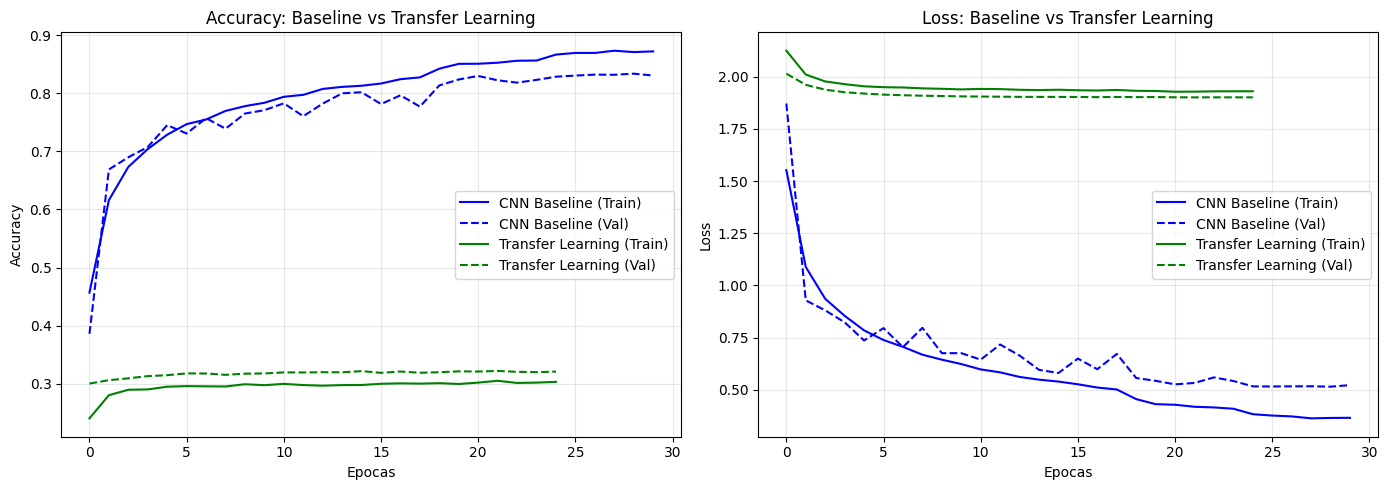

In [13]:
# Grafica comparativa de los modelos entrenados
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history_baseline.history['accuracy'], label='CNN Baseline (Train)', color='blue', linestyle='-')
axes[0].plot(history_baseline.history['val_accuracy'], label='CNN Baseline (Val)', color='blue', linestyle='--')
axes[0].plot(history_transfer.history['accuracy'], label='Transfer Learning (Train)', color='green', linestyle='-')
axes[0].plot(history_transfer.history['val_accuracy'], label='Transfer Learning (Val)', color='green', linestyle='--')
axes[0].set_xlabel('Epocas')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy: Baseline vs Transfer Learning')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history_baseline.history['loss'], label='CNN Baseline (Train)', color='blue', linestyle='-')
axes[1].plot(history_baseline.history['val_loss'], label='CNN Baseline (Val)', color='blue', linestyle='--')
axes[1].plot(history_transfer.history['loss'], label='Transfer Learning (Train)', color='green', linestyle='-')
axes[1].plot(history_transfer.history['val_loss'], label='Transfer Learning (Val)', color='green', linestyle='--')
axes[1].set_xlabel('Epocas')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss: Baseline vs Transfer Learning')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

 ### 5.2 Tabla comparativa de modelos

 | Modelo | Train Acc | Val Acc | Parámetros | Entrenables | Épocas |
 |--------|-----------|---------|------------|-------------|--------|
 | **CNN Baseline** | 87.18% | 83.03% (mejor: 83.35%) | ~362K | ~362K | 30 |
 | **Transfer Learning** | 30.34% | 32.10% (mejor: 32.21%) | ~2.2M | ~12K | 25 |
 | **Fine-Tuning** | 58.64% | 60.47% | ~2.2M | ~2.2M | 15 |

 #### Reflexión final

 En esta práctica observamos que, **con esta configuración y esta corrida**, la CNN baseline logró el mejor desempeño de validación (~83.35%), mientras que Transfer
Learning y Fine-Tuning quedaron por debajo.

 Esto no contradice la teoría: el rendimiento de transferencia depende mucho de la preparación de datos, el preprocesamiento correcto para el modelo base, la
resolución de entrada y los hiperparámetros (especialmente *learning rate* y esquema de congelamiento/descongelamiento).
  En la práctica profesional, Transfer Learning sigue siendo un enfoque estándar, pero requiere ajuste cuidadoso para superar un baseline sólido.
